# Credit Risk Scoring & Expected Loss Analysis
## Notebook 4: PD Modelling & Probability Calibration
Strict calibration selection via nested out-of-fold evaluation on the training set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss, roc_curve, precision_recall_curve, auc
from sklearn.inspection import permutation_importance
import statsmodels.stats.proportion as smprop

df = pd.read_csv('../data/processed/cleaned_credit_card_data.csv')
X = df.drop('DEFAULT_NEXT_MONTH', axis=1)
y = df['DEFAULT_NEXT_MONTH']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')


Train: 24000 | Test: 6000


### 1. Calibration Selection (Nested Out-of-Fold on Train)

In [2]:
base_rf = RandomForestClassifier(n_estimators=100, min_samples_leaf=20, n_jobs=-1, random_state=42)

cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_raw = np.zeros(len(X_train))
oof_sig = np.zeros(len(X_train))
oof_iso = np.zeros(len(X_train))

X_train_arr = X_train.values
y_train_arr = y_train.values

for train_idx, val_idx in cv_outer.split(X_train_arr, y_train_arr):
    X_tr, y_tr = X_train_arr[train_idx], y_train_arr[train_idx]
    X_val, y_val = X_train_arr[val_idx], y_train_arr[val_idx]
    
    # Raw RF
    rf_fold = RandomForestClassifier(n_estimators=100, min_samples_leaf=20, n_jobs=-1, random_state=42)
    rf_fold.fit(X_tr, y_tr)
    oof_raw[val_idx] = rf_fold.predict_proba(X_val)[:, 1]
    
    # Sigmoid
    cal_sig = CalibratedClassifierCV(RandomForestClassifier(n_estimators=100, min_samples_leaf=20, n_jobs=-1, random_state=42), cv=5, method='sigmoid')
    cal_sig.fit(X_tr, y_tr)
    oof_sig[val_idx] = cal_sig.predict_proba(X_val)[:, 1]
    
    # Isotonic
    cal_iso = CalibratedClassifierCV(RandomForestClassifier(n_estimators=100, min_samples_leaf=20, n_jobs=-1, random_state=42), cv=5, method='isotonic')
    cal_iso.fit(X_tr, y_tr)
    oof_iso[val_idx] = cal_iso.predict_proba(X_val)[:, 1]

brier_raw = brier_score_loss(y_train_arr, oof_raw)
brier_sig = brier_score_loss(y_train_arr, oof_sig)
brier_iso = brier_score_loss(y_train_arr, oof_iso)

print(f"OOF Brier - Raw:      {brier_raw:.5f} | Log-loss: {log_loss(y_train_arr, oof_raw):.5f}")
print(f"OOF Brier - Sigmoid:  {brier_sig:.5f} | Log-loss: {log_loss(y_train_arr, oof_sig):.5f}")
print(f"OOF Brier - Isotonic: {brier_iso:.5f} | Log-loss: {log_loss(y_train_arr, oof_iso):.5f}")

best_calib_brier = min(brier_sig, brier_iso)
if (brier_raw - best_calib_brier) < 0.0005:
    selected_method = 'raw'
    print("\nRule: Improvement from calibration is < 0.0005 Brier. Selecting RAW RF.")
else:
    selected_method = 'isotonic' if brier_iso < brier_sig else 'sigmoid'
    print(f"\nRule: Improvement >= 0.0005. Selecting {selected_method.upper()}.")


OOF Brier - Raw:      0.13379 | Log-loss: 0.42653
OOF Brier - Sigmoid:  0.13390 | Log-loss: 0.42778
OOF Brier - Isotonic: 0.13368 | Log-loss: 0.42726

Rule: Improvement from calibration is < 0.0005 Brier. Selecting RAW RF.


### 2. Final Models & Test Evaluation

In [3]:
# Train final models on full train set
lr_pipe = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(random_state=42, max_iter=1000))])
lr_pipe.fit(X_train, y_train)

rf_raw = RandomForestClassifier(n_estimators=100, min_samples_leaf=20, n_jobs=-1, random_state=42)
rf_raw.fit(X_train, y_train)

rf_sig = CalibratedClassifierCV(rf_raw, cv=5, method='sigmoid')
rf_sig.fit(X_train, y_train)

rf_iso = CalibratedClassifierCV(rf_raw, cv=5, method='isotonic')
rf_iso.fit(X_train, y_train)

models = {'LR (Raw)': lr_pipe, 'RF (Raw)': rf_raw, 'RF (Sigmoid)': rf_sig, 'RF (Isotonic)': rf_iso}
exposure = X_test['LIMIT_BAL']
lgd = 0.45
realized_loss = (y_test * exposure * lgd).sum()

results = []
base_brier = y_train.mean() * (1 - y_train.mean())

for name, model in models.items():
    preds = model.predict_proba(X_test)[:, 1]
    auc_v = roc_auc_score(y_test, preds)
    fpr, tpr, _ = roc_curve(y_test, preds)
    precision, recall, _ = precision_recall_curve(y_test, preds)
    brier = brier_score_loss(y_test, preds)
    
    results.append({
        'Model': name,
        'ROC-AUC': auc_v,
        'Gini': 2 * auc_v - 1,
        'KS': max(tpr - fpr),
        'PR-AUC': auc(recall, precision),
        'Brier': brier,
        'Brier Skill': 1 - (brier / base_brier),
        'Log-Loss': log_loss(y_test, preds),
        'CITL (Bias)': preds.mean() - y_test.mean(),
        'Model EL': (preds * exposure * lgd).sum(),
        'Realized Loss': realized_loss
    })

res_df = pd.DataFrame(results).set_index('Model')
display(res_df.round(4))


,ROC-AUC,Gini,KS,PR-AUC,Brier,Brier Skill,Log-Loss,CITL (Bias),Model EL,Realized Loss
Model,,,,,,,,,,
LR (Raw),0.7079,0.4158,0.3638,0.4938,0.1467,0.1486,0.4710,0.0000,7.664393e+07,82155456.0
RF (Raw),0.7748,0.5495,0.4284,0.5520,0.1356,0.2127,0.4321,0.0007,7.938292e+07,82155456.0
RF (Sigmoid),0.7756,0.5512,0.4300,0.5541,0.1359,0.2113,0.4332,0.0004,8.065285e+07,82155456.0
RF (Isotonic),0.7754,0.5509,0.4261,0.5550,0.1355,0.2133,0.4318,-0.0001,7.812862e+07,82155456.0


### 3. V1.1 'Before' State EXACT Brier Score (Balanced RF on Held-out Test Set)

In [4]:
rf_v1 = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
rf_v1.fit(X_train, y_train)
preds_v1 = rf_v1.predict_proba(X_test)[:, 1]
print(f"v1.1 Balanced RF Test Brier: {brier_score_loss(y_test, preds_v1):.4f}")
print(f"v1.1 Balanced RF Test AUC: {roc_auc_score(y_test, preds_v1):.4f}")
print(f"v1.1 Balanced RF CITL: {preds_v1.mean() - y_test.mean():.4f}")


v1.1 Balanced RF Test Brier: 0.1764
v1.1 Balanced RF Test AUC: 0.7750
v1.1 Balanced RF CITL: 0.1963


### 4. Reliability Diagram (Balanced vs Raw vs Calibrated)

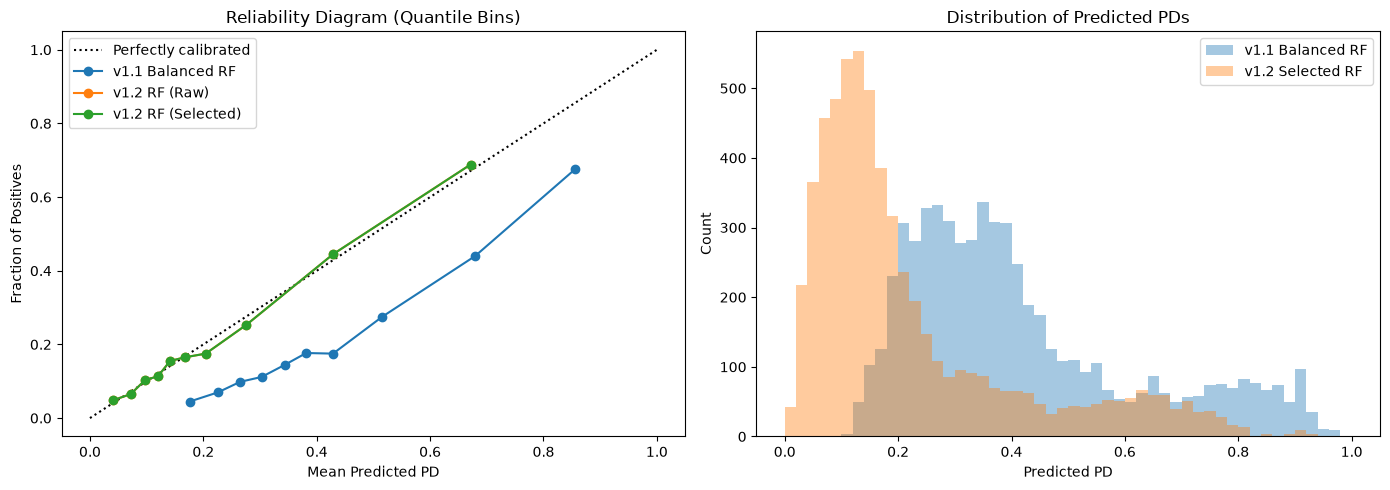

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reliability curve
ax1 = axes[0]
ax1.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

for name, p_arr in [("v1.1 Balanced RF", preds_v1), ("v1.2 RF (Raw)", models['RF (Raw)'].predict_proba(X_test)[:,1]), ("v1.2 RF (Selected)", models['RF (' + selected_method.capitalize() + ')'].predict_proba(X_test)[:,1] if selected_method != 'raw' else models['RF (Raw)'].predict_proba(X_test)[:,1])]:
    prob_true, prob_pred = calibration_curve(y_test, p_arr, n_bins=10, strategy='quantile')
    ax1.plot(prob_pred, prob_true, marker='o', label=name)

ax1.set_xlabel("Mean Predicted PD")
ax1.set_ylabel("Fraction of Positives")
ax1.set_title("Reliability Diagram (Quantile Bins)")
ax1.legend()

# Histogram
ax2 = axes[1]
ax2.hist(preds_v1, range=(0, 1), bins=50, alpha=0.4, label='v1.1 Balanced RF')
selected_preds = models['RF (' + selected_method.capitalize() + ')'].predict_proba(X_test)[:,1] if selected_method != 'raw' else models['RF (Raw)'].predict_proba(X_test)[:,1]
ax2.hist(selected_preds, range=(0, 1), bins=50, alpha=0.4, label='v1.2 Selected RF')
ax2.set_xlabel("Predicted PD")
ax2.set_ylabel("Count")
ax2.set_title("Distribution of Predicted PDs")
ax2.legend()

plt.tight_layout()
plt.savefig('../figures/reliability_diagram.png', dpi=150)
plt.show()


### 5. ROC Curve Comparison

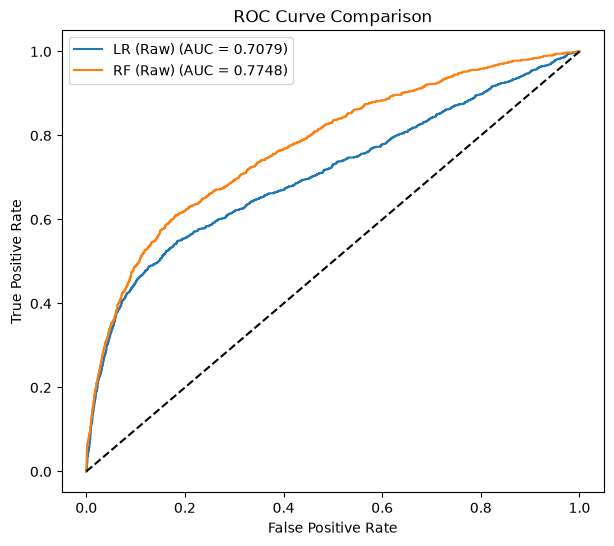

In [6]:
plt.figure(figsize=(7,6))
for name in ['LR (Raw)', 'RF (Raw)']:
    fpr, tpr, _ = roc_curve(y_test, models[name].predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, models[name].predict_proba(X_test)[:,1]):.4f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig('../figures/roc_curve_comparison.png', dpi=150)
plt.show()


### 6. Permutation Feature Importance (Test Set, AUC)

C:\Users\Berk\AppData\Local\Temp\ipykernel_6884\822292957.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, tick_labels=X_test.columns[sorted_idx])


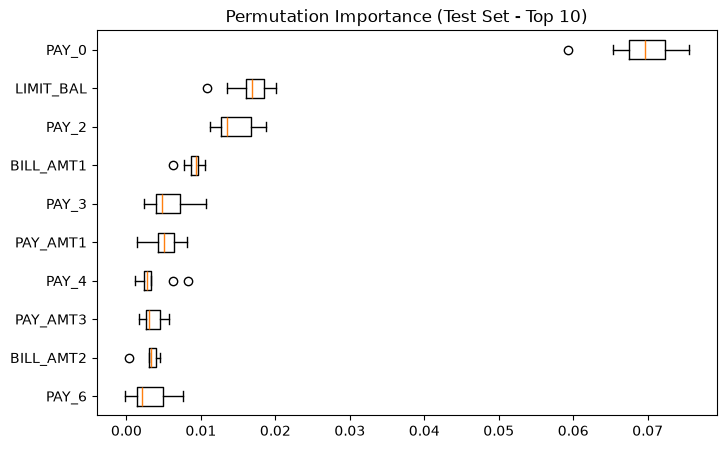

In [7]:
result = permutation_importance(models['RF (Raw)'], X_test, y_test, scoring='roc_auc', n_repeats=10, random_state=42, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()[-10:]

plt.figure(figsize=(8,5))
plt.boxplot(result.importances[sorted_idx].T, vert=False, tick_labels=X_test.columns[sorted_idx])
plt.title("Permutation Importance (Test Set - Top 10)")
plt.savefig('../figures/feature_importance.png', dpi=150)
plt.show()


### 7. Decile Table (Full) with Wilson CIs & Hosmer-Lemeshow

In [8]:
df_test = pd.DataFrame({'Actual': y_test, 'PD': selected_preds, 'Exposure': exposure})
df_test['Decile'] = pd.qcut(df_test['PD'].rank(method='first'), 10, labels=False)
df_test['Decile'] = 10 - df_test['Decile']

hl_stat = 0
rows = []
for d in range(1, 11):
    subset = df_test[df_test['Decile'] == d]
    n = len(subset)
    obs = subset['Actual'].sum()
    avg_pd = subset['PD'].mean()
    exp_d = avg_pd * n
    
    ci_low, ci_upp = smprop.proportion_confint(obs, n, method='wilson')
    hl_stat += ((obs - exp_d)**2) / (exp_d * (1 - avg_pd))
    
    rows.append({
        'Decile': d, 'Clients': n, 'Avg_PD': avg_pd, 'Expected_Def': exp_d,
        'Obs_Default': obs/n, 'Wilson_95CI': f"[{ci_low:.3f}, {ci_upp:.3f}]",
        'Obs_Count': obs, 'Exposure': subset['Exposure'].sum()
    })

decile_df = pd.DataFrame(rows).set_index('Decile')
display(decile_df)
print(f"Hosmer-Lemeshow Statistic: {hl_stat:.2f}")


,Clients,Avg_PD,Expected_Def,Obs_Default,Wilson_95CI,Obs_Count,Exposure
Decile,,,,,,,
1,600,0.671361,402.816622,0.688333,"[0.650, 0.724]",413,60400000
2,600,0.428908,257.344737,0.445000,"[0.406, 0.485]",267,70210000
3,600,0.276033,165.620087,0.253333,"[0.220, 0.290]",152,77357680
4,600,0.204202,122.521332,0.175000,"[0.147, 0.207]",105,78320000
5,600,0.167444,100.466485,0.165000,"[0.137, 0.197]",99,88530000
6,600,0.141339,84.803642,0.155000,"[0.128, 0.186]",93,101340000
7,600,0.119886,71.931324,0.113333,"[0.090, 0.141]",68,101820000
8,600,0.097355,58.412883,0.103333,"[0.081, 0.130]",62,118510000
9,600,0.071770,43.062238,0.065000,"[0.048, 0.088]",39,137690000


Hosmer-Lemeshow Statistic: 8.92


### 8. Save Predictions

In [9]:
preds_out = pd.DataFrame({
    'Actual_Default': y_test.values,
    'Credit_Limit': exposure.values,
    'PD_LR': models['LR (Raw)'].predict_proba(X_test)[:, 1],
    'PD_RF_Selected': selected_preds
})
preds_out.to_csv('../data/processed/test_predictions.csv', index=False)
